In [197]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from matplotlib.ticker import MaxNLocator

In [198]:
np.random.seed(0)
torch.manual_seed(0)
num_points = 300
x = np.random.uniform(-10, 10, num_points)
y = np.sin(3*x)
num_neurons = 50
num_epochs = 200000
save_interval = 20

In [199]:
x_tensor = torch.tensor(x, dtype=torch.float32).view(-1, 1)
y_tensor = torch.tensor(y, dtype=torch.float32).view(-1, 1)

In [200]:
# Разделение данных на обучающую, валидационную и тестовую выборки
x_train, x_temp, y_train, y_temp = train_test_split(x, y, test_size=0.4, random_state=0)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=0)

x_train_tensor = torch.tensor(x_train, dtype=torch.float32).view(-1, 1)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
x_val_tensor = torch.tensor(x_val, dtype=torch.float32).view(-1, 1)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)
x_test_tensor = torch.tensor(x_test, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

In [201]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.hidden_layer = nn.Linear(1, num_neurons)
        self.activation = nn.Tanh()
        self.output_layer = nn.Linear(num_neurons, 1)

        # Для хранения истории весов
        self.hidden_weights_history = []
        self.output_weights_history = []
        self.hidden_biases_history = []
        self.output_biases_history = []
    
    def forward(self, x):
        self.hidden_output = self.activation(self.hidden_layer(x))
        return self.output_layer(self.hidden_output)
    
    def get_hidden_outputs(self, x):
        with torch.no_grad():
            hidden_output = self.activation(self.hidden_layer(x))
        return hidden_output
    
    def track_weights(self):
        with torch.no_grad():
            # Сохраняем веса скрытого слоя (5 нейронов, 1 вход каждый)
            self.hidden_weights_history.append(self.hidden_layer.weight.detach().clone().numpy())
            self.hidden_biases_history.append(self.hidden_layer.bias.detach().clone().numpy())
            
            # Сохраняем веса выходного слоя (1 нейрон, 5 входов)
            self.output_weights_history.append(self.output_layer.weight.detach().clone().numpy())
            self.output_biases_history.append(self.output_layer.bias.detach().clone().numpy())

In [202]:
model = Net()

In [203]:
# Предсказания до обучения
with torch.no_grad():
    x_plot = torch.tensor(np.linspace(-10, 10, 300), dtype=torch.float32).view(-1, 1)
    y_pred_before = model(x_plot)
    y_true = np.sin(3 * x_plot.numpy())

In [204]:
# Выходы скрытого слоя до обучения
hidden_outputs_before = model.get_hidden_outputs(x_plot).numpy()

In [205]:
# Начальные веса
model.track_weights()

In [206]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [207]:
train_losses = []
val_losses = []
test_losses = []
epochs_list = []
best_val_loss = float('inf')

for epoch in range(num_epochs):
    outputs = model(x_tensor)
    loss = criterion(outputs, y_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    model.eval()
    with torch.no_grad():
        # Ошибка на обучающей выборке
        train_outputs = model(x_train_tensor)
        train_loss = criterion(train_outputs, y_train_tensor)
        
        # Ошибка на валидационной выборке
        val_outputs = model(x_val_tensor)
        val_loss = criterion(val_outputs, y_val_tensor)
        
        # Ошибка на тестовой выборке
        test_outputs = model(x_test_tensor)
        test_loss = criterion(test_outputs, y_test_tensor)

    
    # Сохранение ошибок
    if epoch % 1000 == 0:
        epochs_list.append(epoch)
        train_losses.append(train_loss.item())
        val_losses.append(val_loss.item())
        test_losses.append(test_loss.item())
    
    if (epoch+1) % save_interval == 0:
        model.track_weights()

    if (epoch+1) % 1000 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}, Train Loss: {train_loss.item():.4f}, Val Loss: {val_loss.item():.4f}, Test Loss: {test_loss.item():.4f}')
    
    if best_val_loss > val_loss:
        best_val_loss = val_loss
    
    if val_loss < 0.001:
        print('Early stopping!')
        break

Epoch [1000/200000], Loss: 0.5048, Train Loss: 0.5057, Val Loss: 0.4287, Test Loss: 0.5784
Epoch [2000/200000], Loss: 0.4498, Train Loss: 0.4401, Val Loss: 0.3912, Test Loss: 0.5373
Epoch [3000/200000], Loss: 0.3860, Train Loss: 0.3666, Val Loss: 0.3484, Test Loss: 0.4817
Epoch [4000/200000], Loss: 0.3467, Train Loss: 0.3238, Val Loss: 0.3174, Test Loss: 0.4447
Epoch [5000/200000], Loss: 0.3257, Train Loss: 0.3051, Val Loss: 0.3010, Test Loss: 0.4121
Epoch [6000/200000], Loss: 0.3054, Train Loss: 0.2855, Val Loss: 0.3015, Test Loss: 0.3690
Epoch [7000/200000], Loss: 0.2676, Train Loss: 0.2540, Val Loss: 0.2850, Test Loss: 0.2909
Epoch [8000/200000], Loss: 0.2356, Train Loss: 0.2319, Val Loss: 0.2568, Test Loss: 0.2254
Epoch [9000/200000], Loss: 0.2135, Train Loss: 0.2146, Val Loss: 0.2442, Test Loss: 0.1797
Epoch [10000/200000], Loss: 0.2019, Train Loss: 0.2057, Val Loss: 0.2307, Test Loss: 0.1619
Epoch [11000/200000], Loss: 0.1933, Train Loss: 0.1993, Val Loss: 0.2165, Test Loss: 0.15

In [208]:
# Предсказания после обучения
with torch.no_grad():
    y_pred_after = model(x_plot)

In [209]:
# Выход скрытого слоя после обучения
hidden_outputs_after = model.get_hidden_outputs(x_plot).numpy()

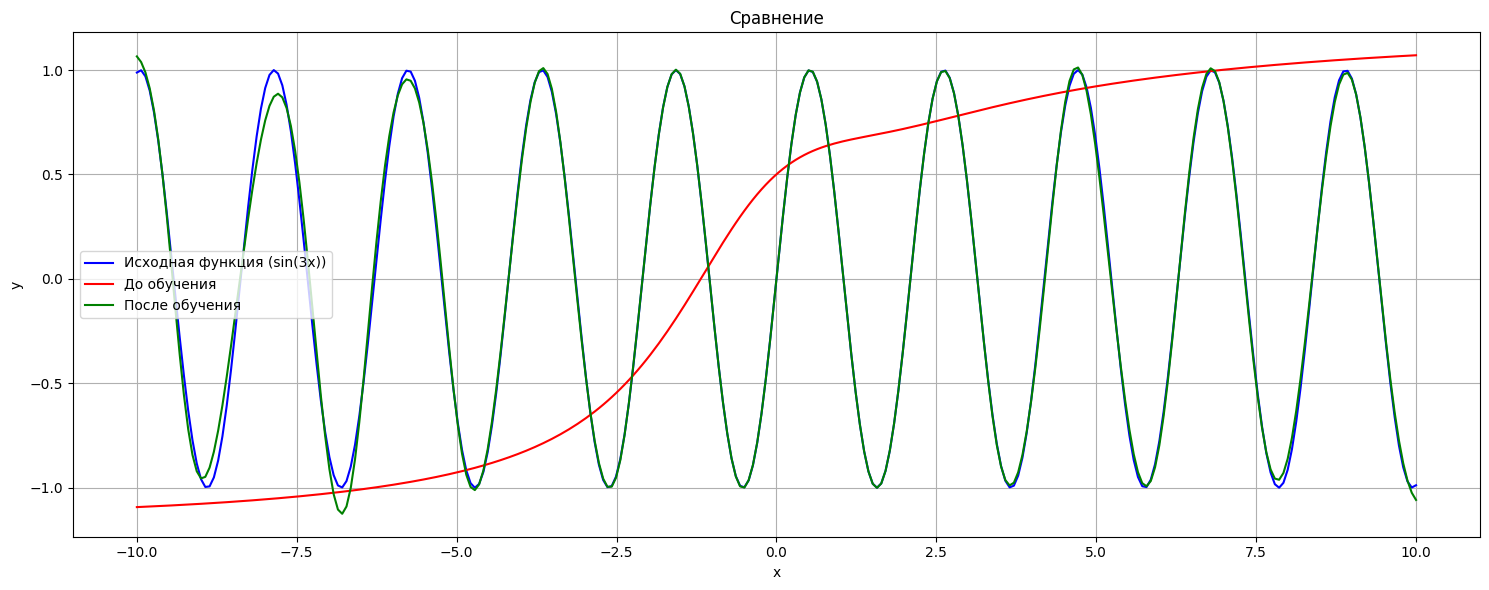

In [210]:
plt.figure(figsize=(15, 6))
plt.plot(x_plot.numpy(), y_true, color='blue', label='Исходная функция (sin(3x))')
plt.plot(x_plot.numpy(), y_pred_before.numpy(), color='red', label='До обучения')
plt.plot(x_plot.numpy(), y_pred_after.numpy(), color='green', label='После обучения')
plt.title('Сравнение')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

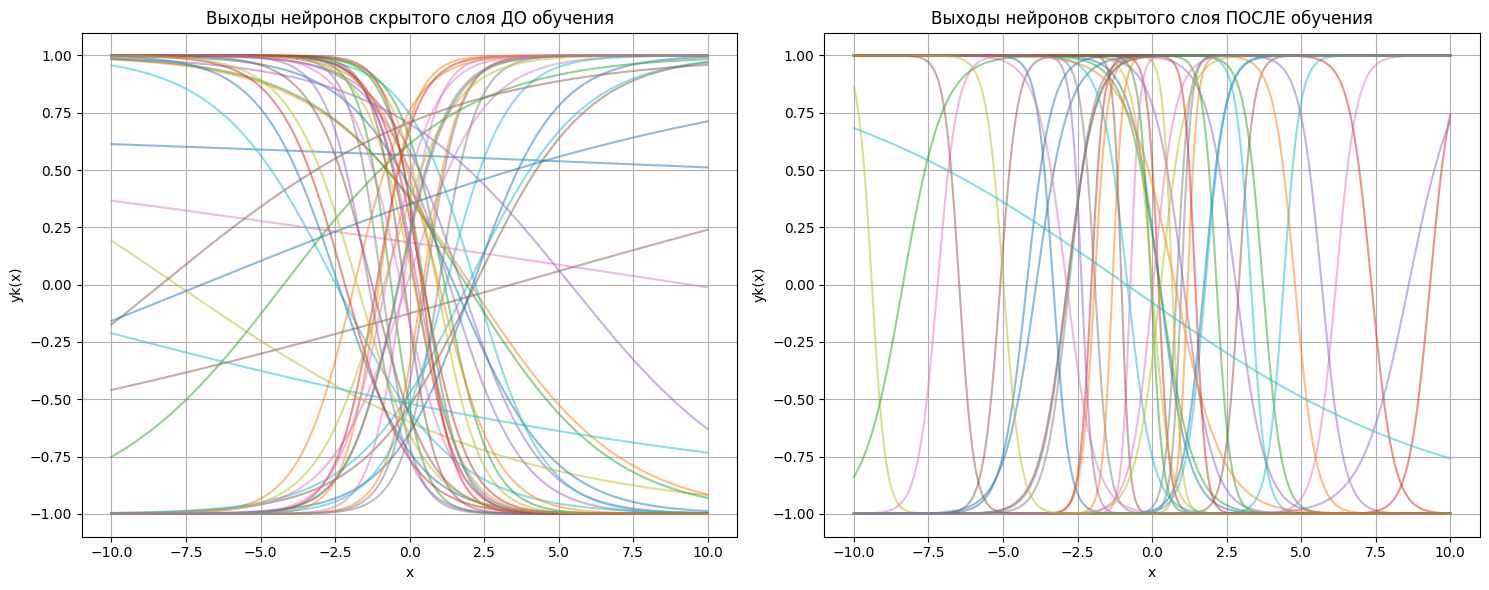

In [211]:
plt.figure(figsize=(15, 6))
# График до обучения
plt.subplot(1, 2, 1)
for i in range(hidden_outputs_before.shape[1]):
    plt.plot(x_plot.numpy(), hidden_outputs_before[:, i], alpha=0.5)
plt.title('Выходы нейронов скрытого слоя ДО обучения')
plt.xlabel('x')
plt.ylabel('yk(x)')
plt.grid(True)

# График после обучения
plt.subplot(1, 2, 2)
for i in range(hidden_outputs_after.shape[1]):
    plt.plot(x_plot.numpy(), hidden_outputs_after[:, i], alpha=0.5)
plt.title('Выходы нейронов скрытого слоя ПОСЛЕ обучения')
plt.xlabel('x')
plt.ylabel('yk(x)')
plt.grid(True)

plt.tight_layout()
plt.show()

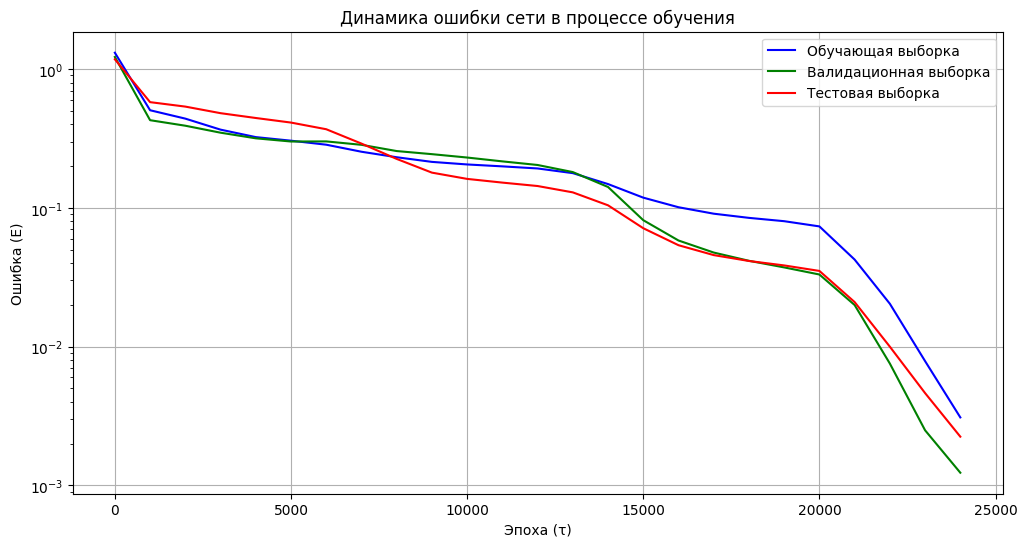

In [212]:
# Визуализация ошибок
plt.figure(figsize=(12, 6))
plt.plot(epochs_list, train_losses, label='Обучающая выборка', color='blue')
plt.plot(epochs_list, val_losses, label='Валидационная выборка', color='green')
plt.plot(epochs_list, test_losses, label='Тестовая выборка', color='red')
plt.title('Динамика ошибки сети в процессе обучения')
plt.xlabel('Эпоха (τ)')
plt.ylabel('Ошибка (E)')
plt.yscale('log')
plt.legend()
plt.grid(True)
plt.show()

In [213]:
hidden_weights = np.array(model.hidden_weights_history)
output_weights = np.array(model.output_weights_history)
hidden_biases = np.array(model.hidden_biases_history)
output_biases = np.array(model.output_biases_history)

C:\Users\4842394\AppData\Local\Temp\ipykernel_16848\1332175497.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', hidden_weights.shape[1])


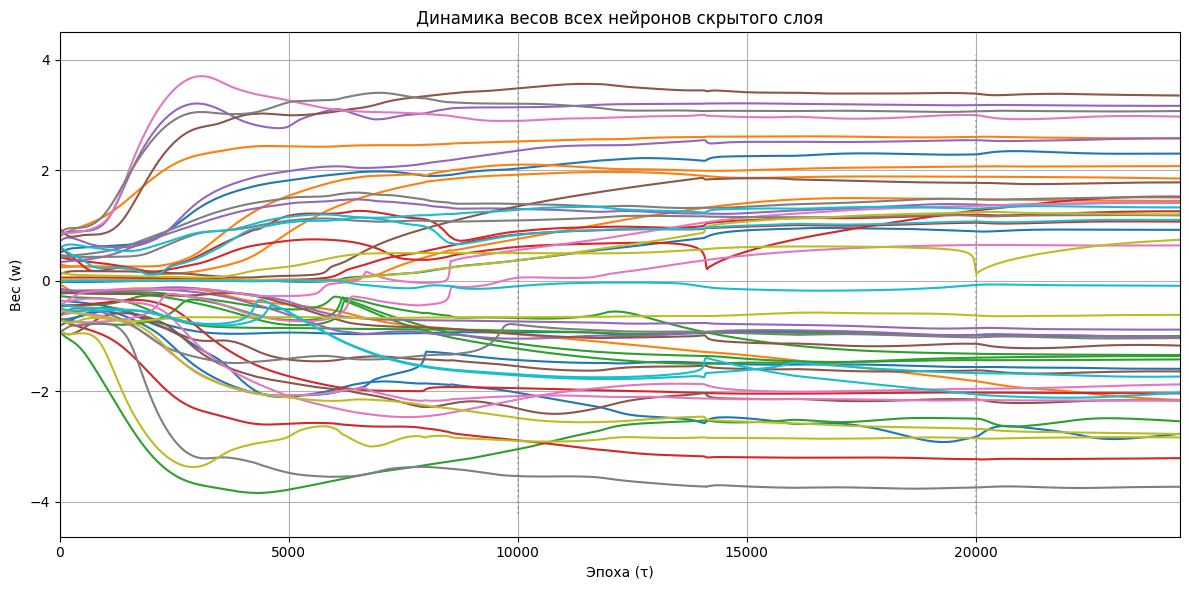

In [214]:
# Веса скрытого слоя
plt.figure(figsize=(12, 6))

colors = plt.cm.get_cmap('tab10', hidden_weights.shape[1])

epochs_saved = np.arange(0, hidden_weights.shape[0]) * save_interval

for neuron in range(hidden_weights.shape[1]):
    for input in range(hidden_weights.shape[2]):
        plt.plot(epochs_saved,
                 hidden_weights[:, neuron, input],
                 color=colors(neuron),
                 linestyle='-' if input == 0 else '--',
                 label=f'Нейрон {neuron+1}' if input == 0 else f'Нейрон {neuron+1} вход {input+1}')

plt.title('Динамика весов всех нейронов скрытого слоя')
plt.xlabel('Эпоха (τ)')
plt.ylabel('Вес (w)')
plt.grid(True)
plt.tight_layout()

if hidden_weights.shape[1] > 1:
    ymin, ymax = plt.ylim()
    for neuron in range(1, hidden_weights.shape[1]):
        plt.vlines(num_epochs * 0.05 * neuron, ymin, ymax, 
                 colors='gray', linestyles='dotted', alpha=0.5)
        
plt.xlim(0, epochs_saved.max())

plt.show()


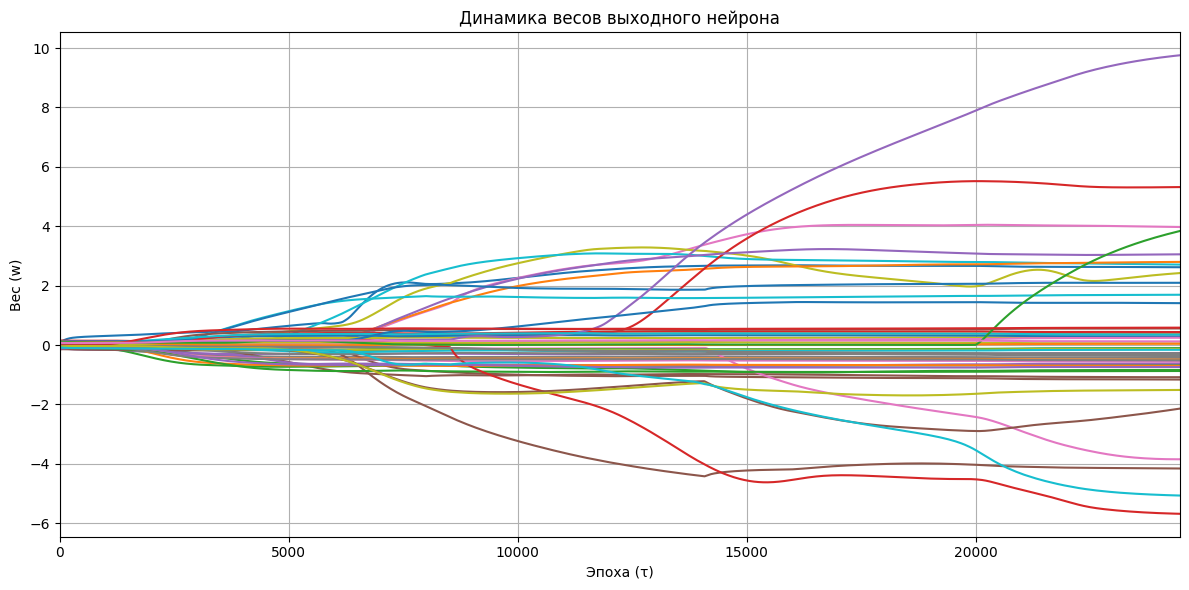

In [218]:
# Веса выходного слоя
plt.figure(figsize=(12, 6))

epochs_saved = np.arange(0, output_weights.shape[0]) * save_interval

for neuron in range(output_weights.shape[2]):
    plt.plot(epochs_saved, 
             output_weights[:, 0, neuron],
             label=f'Нейрон {neuron+1}')

plt.title('Динамика весов выходного нейрона')
plt.xlabel('Эпоха (τ)')
plt.ylabel('Вес (w)')
plt.grid(True)
plt.xlim(0, epochs_saved.max())
plt.tight_layout()
plt.show()


In [219]:
with torch.no_grad():
    # Предсказания
    train_outputs = model(x_train_tensor)
    val_outputs = model(x_val_tensor)
    test_outputs = model(x_test_tensor)

    # Считаем ошибки
    train_mse = criterion(train_outputs, y_train_tensor)
    val_mse = criterion(val_outputs, y_val_tensor)
    test_mse = criterion(test_outputs, y_test_tensor)

    # Считаем RMSE
    train_rmse = torch.sqrt(train_mse)
    val_rmse = torch.sqrt(val_mse)
    test_rmse = torch.sqrt(test_mse)

print(f"Train MSE: {train_mse.item():.6f}, RMSE: {train_rmse.item():.6f}")
print(f"Val MSE: {val_mse.item():.6f}, RMSE: {val_rmse.item():.6f}")
print(f"Test MSE: {test_mse.item():.6f}, RMSE: {test_rmse.item():.6f}")

Train MSE: 0.002058, RMSE: 0.045368
Val MSE: 0.001000, RMSE: 0.031621
Test MSE: 0.001657, RMSE: 0.040707


In [220]:
with torch.no_grad():
    train_outputs = model(x_train_tensor)
    val_outputs = model(x_val_tensor)
    test_outputs = model(x_test_tensor)

    # Абсолютные ошибки
    train_abs_errors = torch.abs(y_train_tensor - train_outputs)
    val_abs_errors = torch.abs(y_val_tensor - val_outputs)
    test_abs_errors = torch.abs(y_test_tensor - test_outputs)

    # Максимальные абсолютные ошибки
    train_max_abs_error = train_abs_errors.max()
    val_max_abs_error = val_abs_errors.max()
    test_max_abs_error = test_abs_errors.max()

print(f"Train Max Absolute Error: {train_max_abs_error.item():.6f}")
print(f"Val Max Absolute Error: {val_max_abs_error.item():.6f}")
print(f"Test Max Absolute Error: {test_max_abs_error.item():.6f}")


Train Max Absolute Error: 0.155094
Val Max Absolute Error: 0.126476
Test Max Absolute Error: 0.148133
